**Data required:** Place `participant_data.csv` in `01_empirical/data/`. See `01_empirical/data/README.md` for the data source (Sparkman et al. 2022, *Nature Communications*).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

SMALL  = 11
MEDIUM = 13
DPI    = 300

matplotlib.rc('font',   size=SMALL)
matplotlib.rc('axes',   titlesize=MEDIUM)
matplotlib.rc('axes',   labelsize=MEDIUM)
matplotlib.rc('xtick',  labelsize=SMALL)
matplotlib.rc('ytick',  labelsize=SMALL)

COL_BLACK = '#222222'

# Survey column mappings
PARTY_COL = 'QPID1'

# Media columns (GTS3): threshold >= 3 means 'at least once per week'
MEDIA_COLS = {
    'Lib':  'GRID_GTS3_8_GTS3',   # Other liberal outlets
    'CNN':  'GRID_GTS3_1_GTS3',   # Cable news (CNN/MSNBC)
    'NYT':  'GRID_GTS3_3_GTS3',   # National papers (NYT/HuffPo/WaPo)
    'ABC':  'GRID_GTS3_4_GTS3',   # TV news (ABC/CBS/NBC)
    'NPR':  'GRID_GTS3_5_GTS3',   # NPR
    'FOX':  'GRID_GTS3_6_GTS3',   # FOX News
    'Cons': 'GRID_GTS3_7_GTS3',   # Other conservative outlets
}

# Misperception columns (GTS1): actual - estimated
# Actuals from YPCCC (Worried) and Sparkman et al. Table 1 (all others)
POLICY_COLS = [
    ('GRID_GTS1_1_GTS1', 66, 'Worried about climate'),
    ('GRID_GTS1_2_GTS1', 66, 'Carbon tax'),
    ('GRID_GTS1_3_GTS1', 80, 'Siting RE'),
    ('GRID_GTS1_4_GTS1', 66, '100% RE'),
    ('GRID_GTS1_5_GTS1', 66, 'Green New Deal'),
]

# Single-line labels for rotated x-axis
MEDIA_LABELS = [
    'Other Liberal Outlets',
    'Cable News (CNN/MSNBC)',
    'National Papers (NYT/HuffPo/WaPo)',
    'TV News (ABC/CBS/NBC)',
    'NPR',
    'FOX News',
    'Other Conservative Outlets',
]

POLICY_LABELS = [p[2] for p in POLICY_COLS]

In [5]:
from pyprojroot import here

df = pd.read_csv(here() / '01_empirical' / 'data' / 'participant_data.csv')

# Binary media consumption: True if >= 3 (once per week or more)
for key, col in MEDIA_COLS.items():
    df[key] = df[col] >= 3

# Misperception = actual support - estimated support
for col, actual, label in POLICY_COLS:
    df[label] = actual - df[col]

# Drop rows missing any media or policy column
media_keys   = list(MEDIA_COLS.keys())
policy_names = POLICY_LABELS
df_media = df[media_keys + policy_names].dropna()

print(f'Respondents with complete media + policy data: {len(df_media)}')

Respondents with complete media + policy data: 6119


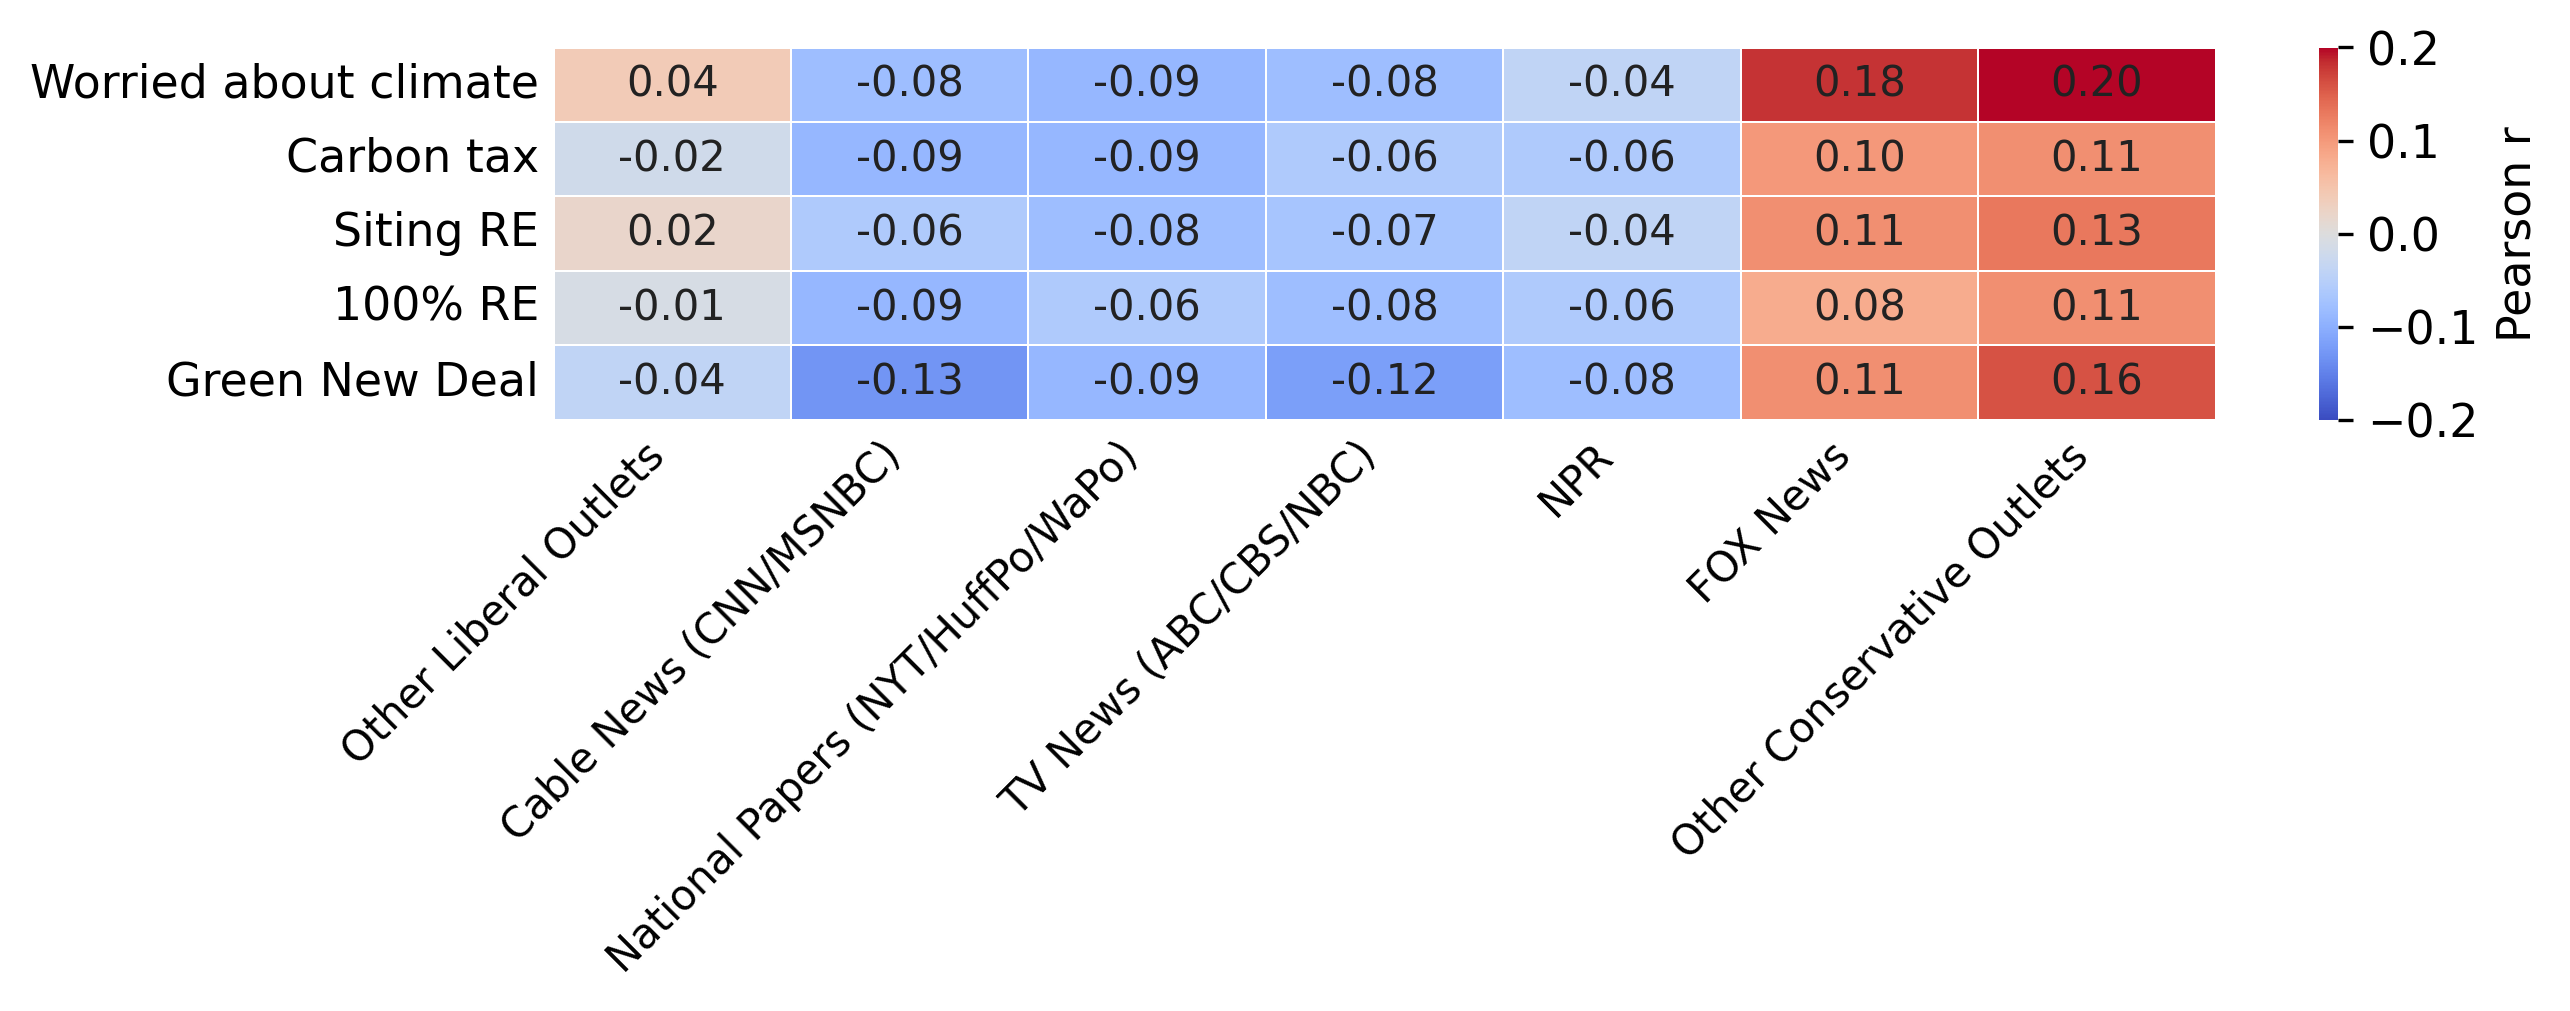

In [6]:
# Pearson r = point-biserial r when one variable is binary — appropriate for binary media × continuous misperception
cor_matrix = np.zeros((len(policy_names), len(media_keys)))
for i, policy in enumerate(policy_names):
    for j, media in enumerate(media_keys):
        cor_matrix[i, j] = round(df_media[media].corr(df_media[policy]), 2)

fig, ax = plt.subplots(figsize=(9, 3.5), dpi=DPI)

sns.heatmap(
    cor_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=MEDIA_LABELS,
    yticklabels=POLICY_LABELS,
    cmap='coolwarm',
    vmin=-0.2,
    vmax=0.2,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': SMALL - 1, 'color': COL_BLACK},
    ax=ax,
)

ax.set_xticklabels(MEDIA_LABELS, rotation=45, ha='right', fontsize=SMALL - 1)
ax.set_yticklabels(POLICY_LABELS, rotation=0, fontsize=SMALL)
ax.tick_params(length=0)

ax.collections[0].colorbar.set_label('Pearson r', size=SMALL)

fig.tight_layout()

fig.savefig(str(here() / "figures" / "correlation_matrix.pdf"), bbox_inches='tight')
plt.show()


In [7]:
# Verify: Spearman rho vs Pearson r for each media x policy pair
from scipy.stats import spearmanr

print(f"{'':30s}  {'Pearson r':>10}  {'Spearman ρ':>10}  {'diff':>6}")
print("-" * 62)
for i, policy in enumerate(policy_names):
    for j, media in enumerate(media_keys):
        pearson  = cor_matrix[i, j]
        spearman = round(spearmanr(df_media[media], df_media[policy]).statistic, 2)
        diff     = abs(pearson - spearman)
        print(f"{policy:20s} x {media:4s}  {pearson:>10.2f}  {spearman:>10.2f}  {diff:>6.2f}")

                                 Pearson r  Spearman ρ    diff
--------------------------------------------------------------
Worried about climate x Lib         0.04        0.04    0.00
Worried about climate x CNN        -0.08       -0.08    0.00
Worried about climate x NYT        -0.09       -0.09    0.00
Worried about climate x ABC        -0.08       -0.07    0.01
Worried about climate x NPR        -0.04       -0.04    0.00
Worried about climate x FOX         0.18        0.18    0.00
Worried about climate x Cons        0.20        0.20    0.00
Carbon tax           x Lib        -0.02       -0.01    0.01
Carbon tax           x CNN        -0.09       -0.09    0.00
Carbon tax           x NYT        -0.09       -0.09    0.00
Carbon tax           x ABC        -0.06       -0.06    0.00
Carbon tax           x NPR        -0.06       -0.06    0.00
Carbon tax           x FOX         0.10        0.11    0.01
Carbon tax           x Cons        0.11        0.12    0.01
Siting RE            x Lib 

**Figure S1.**
Pearson correlations between binary media consumption (watching a given outlet at least once per week) and group-level misperception $\beta_\text{group}$ for five climate positions, from Sparkman et al.'s survey [Sparkman et al., 2022].
Media outlets are ordered from most liberal-leaning (left) to most conservative-leaning (right).
Positive values (red) indicate that more frequent consumption of a given outlet is associated with greater underestimation of public support; negative values (blue) indicate the opposite.
Conservative-leaning outlets (Fox News, Other Conservative) show the strongest positive associations with misperception across all five issues, while liberal-leaning outlets show weak negative associations.

---

**LaTeX caption:**

```latex
\begin{figure}[t!]
    \centering
    \includegraphics[width=\linewidth]{figures/correlation_matrix.pdf}
    \caption{Pearson correlations between binary media consumption (watching a given outlet
    at least once per week) and group-level misperception $\beta_{\text{group}}$ for five
    climate positions, from Sparkman et al.'s survey \cite{sparkman2022americans}.
    Media outlets are ordered from most liberal-leaning (left) to most conservative-leaning (right).
    Positive values (red) indicate that more frequent consumption of a given outlet is associated
    with greater underestimation of public support; negative values (blue) indicate the opposite.
    Conservative-leaning outlets (Fox News, Other Conservative) show the strongest positive
    associations with misperception across all five issues, while liberal-leaning outlets
    show weak negative associations.}
    \label{fig:correlation}
\end{figure}
```